Connected to wzx (Python 3.9.20)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import glob
import matplotlib.dates as mdates
from pylab import *
from matplotlib import dates, ticker
from scipy import stats
import xarray as xr
import matplotlib.path as mpath
from datetime import datetime, timedelta
from dateutil.relativedelta import relativedelta
import pandas as pd
import scipy.signal as signal
import cmaps
from mpl_toolkits.basemap import Basemap, shiftgrid
from scipy.stats import t
from scipy.signal import detrend


def independent_ttest(mean1,mean2,std1,std2,n1,n2, alpha):
    # calculate means
    # calculate standard errors
    #se1, se2 = sem(data1), sem(data2)
    se1, se2 = std1/sqrt(n1), std2/sqrt(n2)
    # standard error on the difference between the samples
    sed = sqrt(se1**2.0 + se2**2.0)
    # calculate the t statistic
    t_stat = (mean1 - mean2) / sed
    # degrees of freedom
    df = n1 + n2 - 2
    # calculate the critical value
    cv = t.ppf(1.0 - alpha, df)
    # calculate the p-value
    p = (1.0 - t.cdf(abs(t_stat), df)) * 2.0
    # return everything
    return p

def draw_latlon_polygon(bmap, lons, lats, *args, **kwargs):
    '''Plot a polygon in lat/lon coordinates.

    bmap -- Basemap object.
    lons, lats -- Sequences of polygon vertices.
    *args, **kwargs -- Aditional arguments to pyplot.plot().

    You should use 'k-' in *args to draw the lines in color black.

    '''
    if len(lons) != len(lats):
        raise IndexError('lons and lats have different lenghts')
    if lons[-1] != lons[0] or lats[-1] != lats[0]:
        lons = np.concatenate((lons, lons[:1]))
        lats = np.concatenate((lats, lats[:1]))
    n = len(lons) - 1
    res = 10000
    for i in range(n):
        x = np.linspace(lons[i], lons[i + 1], res)
        y = np.linspace(lats[i], lats[i + 1], res)
        x, y = bmap(x, y)
        bmap.plot(x, y, *args, **kwargs)

def sh_project(ax,lon,lat):
    #sps = Basemap(lon_0=180, boundinglat=0, projection='spstere',round=True,resolution='l')
    sps = Basemap(projection='cyl',llcrnrlat=-90,urcrnrlat=60,\
                llcrnrlon=0,urcrnrlon=360,resolution='l')
    sps.ax = ax
    mer = np.arange(0, 360, 60.)
    #par = np.arange(-90, -50, 10.)
    x, y = sps(*np.meshgrid(lon, lat))
    sps.drawmapboundary(fill_color='AntiqueWhite')
    sps.drawparallels([-90,-45,0,45,90], linewidth=1,labels=[True,True,False, True],alpha=0.6,latmax=80)
    sps.drawmeridians([0,60,120,180,240,300,360], linewidth=1,labels=[True,True,False, True],fmt='%g',alpha=0.6,latmax=80)
    sps.drawcoastlines(color='k',linewidth=0.8)
    sps.fillcontinents(color='lightgray', lake_color='aqua')
    return sps,x,y

In [4]:
years = np.linspace(1982,2021,40)
year_min = [1994., 2002., 2003., 2007., 2014.]
year_max = [2004., 2005., 2016., 2018., 2021.]
num_y = 5 

#对读取的SST数据进行处理
fname = 'sst.mnmean.nc'
sst = xr.open_dataset('D:/SST/'+fname)['sst'].loc['1982-01-01':'2021-12-31']


In [3]:
sst.shape

(480, 180, 360)

In [13]:
sst_detrended = detrend(sst,type='linear',axis=0)

In [15]:
sst_detrended.shape

(480, 180, 360)

In [16]:
sst_rsp = sst_detrended.reshape(40,12,180,360)

In [17]:
sst_rsp.shape

(40, 12, 180, 360)

In [49]:
t2mn1 = sst_rsp[np.isin(years,year_max)]
t2mn2 = sst_rsp[np.isin(years,year_min)]

In [51]:
pre_clm_son = t2mn1.mean(axis=0)[8:11].mean(axis=0)
pre_std_son = t2mn1.std(axis=0)[8:11].mean(axis=0)
post_clm_son  = t2mn2.mean(axis=0)[8:11].mean(axis=0)
post_std_son  = t2mn2.std(axis=0)[8:11].mean(axis=0)

comp3 = t2mn1.mean(axis=0)  - t2mn2.mean(axis=0)
corSON3 = comp3[8:11].mean(axis=0)

pval3=np.zeros((180,360),'float')

for i in range(180):
    for j in range(360):
        pval3[i,j] = independent_ttest(pre_clm_son[i,j], post_clm_son[i,j], pre_std_son[i,j],post_std_son[i,j], num_y,num_y,0.1)



In [56]:
file2 =xr.open_dataset('D:/ERA5/ERA5-pressure-level-1x1-resolution-geopotential-1979-2023.nc')
gph500 = file2['z'].sel(level=500).loc['1979-01-01':'2023-12-31']/9.8
dtime2 = pd.date_range(start='1979-01-01', end='2023-12-01',freq='MS')
# temp2 = gph[(dtime2.month==9)|(dtime2.month==10)|(dtime2.month==11)].values.reshape(45,3,181,360).mean(axis=1)
lat2 = file2.latitude.values
lon2 = file2.longitude.values

In [61]:
gph500_detrended = detrend(gph500,type='linear',axis=0)
gph500_rsp = gph500_detrended.reshape(45,12,181,360)

In [67]:
years = np.linspace(1979,2023,45)
t2mn1 = gph500_rsp[np.isin(years,year_max)]
t2mn2 = gph500_rsp[np.isin(years,year_min)]

In [68]:
pre_clm_son = t2mn1.mean(axis=0)[8:11].mean(axis=0)
pre_std_son = t2mn1.std(axis=0)[8:11].mean(axis=0)
post_clm_son  = t2mn2.mean(axis=0)[8:11].mean(axis=0)
post_std_son  = t2mn2.std(axis=0)[8:11].mean(axis=0)

comp3 = t2mn1.mean(axis=0)  - t2mn2.mean(axis=0)
corSON3_gph = comp3[8:11].mean(axis=0)

C:\Users\fzjxw\AppData\Local\Temp\ipykernel_33660\2055794365.py:21: UserWarning: The following kwargs were not used by contour: 'shading'
  im1 = m1_ax1.contourf(x1,y1,corSON3,levels=levels1,extend='both',shading='faceted', antialiased=True,cmap=cmaps.BlueWhiteOrangeRed)


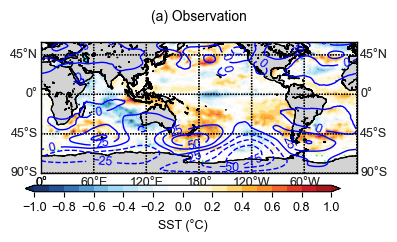

In [69]:
lat1 = sst.lat.values
lon1 = sst.lon.values

#设置全局变量
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['font.size'] = 9
plt.rcParams['lines.linewidth'] = 1
plt.rcParams['axes.titlesize'] = 10  # 轴标题字体大小
plt.rcParams['lines.markersize'] = 1 
mpl.rcParams['hatch.color'] ='springgreen'
mpl.rcParams['hatch.linewidth'] = 0.4

#画图
plt.close()
fig=plt.figure(figsize=(160/25.4, 6))
ax1 = fig.add_subplot(2,3,(1,2))
#m = Basemap(lon_0=180, boundinglat=-50, projection='spstere',round=True,resolution='l')
m1_ax1, x1, y1 = sh_project(ax1, lon1, lat1)
m2_ax1, x2, y2 = sh_project(ax1, lon2, lat2)
levels1=np.linspace(-1,1,21)
im1 = m1_ax1.contourf(x1,y1,corSON3,levels=levels1,extend='both',shading='faceted', antialiased=True,cmap=cmaps.BlueWhiteOrangeRed)
csp = m1_ax1.contourf(x1,y1,1-pval3, levels=[0.95,1] ,colors='none',hatches=['...', None],alpha=0)
#levels2=np.linspace(-100,100,11)
im2 = m2_ax1.contour(x2,y2,corSON3_gph,
                     #levels=levels2,
                     extend='both',colors=['blue'])
ax1.clabel(im2, im2.levels, inline=True)
m1_ax1.fillcontinents(color='lightgray', lake_color='aqua')
ax1.set_title('(a) Observation', position=(0.5, 1.3),pad=15)
cax_ax1 = fig.add_axes([0.1, 0.51, 0.5,0.12], aspect=0.02)
cb1 = fig.colorbar(im1,orientation='horizontal',ticks=levels1[::2],extend='both', extendfrac=0.03,drawedges=False,cax = cax_ax1)
cb1.outline.set_edgecolor('black')
cb1.set_label("SST (°C)")
#fig.suptitle('sea level pressure anomaly (2002)', fontsize=14)
# fig.tight_layout(rect=[0.05,0.1,0.95,0.95])
plt.show()


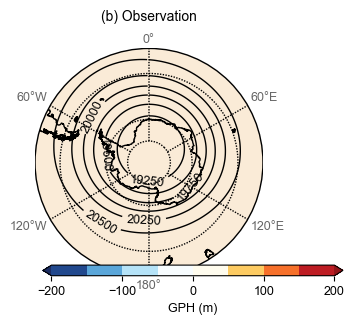

In [74]:
#region 极涡 观测
year_min = [1994., 2002., 2003., 2007., 2014.]
year_max = [2004., 2005., 2016., 2018., 2021.]
num_y = 5
file2 =xr.open_dataset('D:/ERA5/ERA5-pressure-level-1x1-resolution-geopotential-1979-2023.nc')
gph50 = file2['z'].sel(level=50).loc['1979-01-01':'2023-12-31']/9.8
dtime2 = pd.date_range(start='1979-01-01', end='2023-12-01',freq='MS')
# temp2 = gph[(dtime2.month==9)|(dtime2.month==10)|(dtime2.month==11)].values.reshape(45,3,181,360).mean(axis=1)
lat2 = file2.latitude.values
lon2 = file2.longitude.values
years = np.linspace(1979,2023,45)
gph_clm_son = gph50.values.reshape(45,12,181,360).mean(axis=0)[9:11].mean(axis=0)
gph_std_son = gph50.values.reshape(45,12,181,360).std(axis=0)[9:11].mean(axis=0)
fig = plt.figure(figsize=(10,8))
ax2 = fig.add_subplot(2,3,3)
#m = Basemap(lon_0=180, boundinglat=-50, projection='spstere',round=True,resolution='l')
m1_ax2, x1, y1 = sh_project(ax2, lon2, lat2)
#levels2=np.linspace(19250,20250,3)
im6 = m1_ax2.contour(x1,y1,gph_clm_son,
                 #levels=levels2,
                 extend='both',colors=['black'])
ax2.clabel(im6, im6.levels, inline=True)

# m.fillcontinents(color='lightgray', lake_color='aqua')
# cs = m.contourf(x,y, p1, levels=[0.95, 1] ,colors='none',hatches=['///', None],alpha=0)
#cs = m.contourf(x,y, p1, levels=[0.9, 0.95] ,colors='none',hatches=['++', None],alpha=0)
ax2.set_title('(b) Observation', position=(0.5, 1.12),pad=20)
#m.drawcoastlines(color='b')
#ax2.clabel(cf, fontsize=16, inline=1,fmt='%1.f')
cax_ax2 = fig.add_axes([0.68, 0.52, 0.3, 0.1],aspect=0.03)
cb2 = fig.colorbar(im5,orientation='horizontal',
                  ticks=levels1[::2],
                  extend='both', extendfrac=0.03,drawedges=False,
                  cax = cax_ax2
                 )
# cb.ax.tick_params(labelsize=14)
cb2.outline.set_edgecolor('black')
#cb.set_label('GPH500 [meter]',fontsize=16)
#cb.set_label("Sea Level Pressure [hPa]",fontsize=12)
cb2.set_label("GPH (m)")
#fig.suptitle('sea level pressure anomaly (2002)', fontsize=14)
# fig.tight_layout(rect=[0.05,0.1,0.95,0.95])
#plt.savefig('seasonal_std_sea_level_pressure_beafort_high.png',dpi=600,bbox_inches='tight')
# plt.savefig('/stu02/weizx24/figures/0924/Figure10_obs_polarvortex.png' ,dpi=300,bbox_inches='tight')
plt.show()

In [75]:
gph_clm_son 

array([[19827.18 , 19827.18 , 19827.18 , ..., 19827.18 , 19827.18 ,
        19827.18 ],
       [19826.955, 19826.832, 19826.703, ..., 19827.318, 19827.223,
        19827.102],
       [19828.82 , 19828.557, 19828.332, ..., 19829.559, 19829.3  ,
        19829.094],
       ...,
       [19026.426, 19026.312, 19026.244, ..., 19026.652, 19026.557,
        19026.469],
       [19035.457, 19035.441, 19035.43 , ..., 19035.545, 19035.535,
        19035.492],
       [19046.684, 19046.684, 19046.684, ..., 19046.684, 19046.684,
        19046.684]], dtype=float32)

In [76]:
gph50

<xarray.DataArray 'z' (time: 540, lat: 181, lon: 360)>
array([[[19300.06 , 19300.06 , 19300.06 , ..., 19300.06 , 19300.06 ,
         19300.06 ],
        [19275.123, 19274.344, 19274.344, ..., 19275.902, 19275.902,
         19275.123],
        [19252.525, 19251.748, 19250.967, ..., 19254.863, 19254.084,
         19253.305],
        ...,
        [20671.518, 20671.518, 20671.518, ..., 20671.518, 20671.518,
         20671.518],
        [20671.518, 20670.74 , 20670.74 , ..., 20671.518, 20671.518,
         20671.518],
        [20670.74 , 20670.74 , 20670.74 , ..., 20670.74 , 20670.74 ,
         20670.74 ]],

       [[19400.58 , 19400.58 , 19400.58 , ..., 19400.58 , 19400.58 ,
         19400.58 ],
        [19377.982, 19377.982, 19377.203, ..., 19379.543, 19379.543,
         19378.762],
        [19361.62 , 19360.84 , 19360.06 , ..., 19363.957, 19363.178,
         19362.398],
...
        [19101.354, 19100.574, 19100.574, ..., 19102.912, 19102.133,
         19102.133],
        [19095.898, 19095.898, 19095.898, ..., 19096.678, 19096.678,
         19096.678],
        [19094.34 , 19094.34 , 19094.34 , ..., 19094.34 , 19094.34 ,
         19094.34 ]],

       [[19424.738, 19424.738, 19424.738, ..., 19424.738, 19424.738,
         19424.738],
        [19412.27 , 19411.49 , 19411.49 , ..., 19413.049, 19413.049,
         19412.27 ],
        [19398.242, 19397.465, 19396.686, ..., 19400.58 , 19399.803,
         19399.021],
        ...,
        [19922.67 , 19922.67 , 19922.67 , ..., 19922.67 , 19922.67 ,
         19922.67 ],
        [19924.229, 19924.229, 19924.229, ..., 19924.229, 19924.229,
         19924.229],
        [19927.346, 19927.346, 19927.346, ..., 19927.346, 19927.346,
         19927.346]]], dtype=float32)
Coordinates:
  * time     (time) datetime64[ns] 1979-01-01 1979-02-01 ... 2023-12-01
    level    float64 50.0
Dimensions without coordinates: lat, lon

In [77]:
gph50_detrended = detrend(gph50,type='linear',axis=0)
gph50_rsp = gph50_detrended.reshape(45,12,181,360)

In [78]:
gph50_detrended

array([[[-830.9922  , -830.9922  , -830.9922  , ..., -830.9922  ,
         -830.9922  , -830.9922  ],
        [-851.6367  , -852.334   , -852.2168  , ..., -851.1289  ,
         -851.03125 , -851.7129  ],
        [-871.46484 , -872.0957  , -872.6914  , ..., -869.584   ,
         -870.2383  , -870.83594 ],
        ...,
        [1324.582   , 1324.6797  , 1324.8535  , ..., 1324.1504  ,
         1324.2852  , 1324.4219  ],
        [1321.6465  , 1320.9277  , 1320.9727  , ..., 1321.457   ,
         1321.4922  , 1321.5527  ],
        [1316.5781  , 1316.5781  , 1316.5781  , ..., 1316.5781  ,
         1316.5781  , 1316.5781  ]],

       [[-730.53516 , -730.53516 , -730.53516 , ..., -730.53516 ,
         -730.53516 , -730.53516 ],
        [-748.8418  , -748.75977 , -749.4219  , ..., -747.55273 ,
         -747.4551  , -748.1387  ],
        [-762.43555 , -763.0703  , -763.6621  , ..., -760.5547  ,
         -761.209   , -761.80664 ],
        ...,
        [1113.6602  , 1112.9785  , 1113.1523  , ..., 1

In [72]:
gph50.shape 

(540, 181, 360)

In [60]:
gph500_detrended.shape

(540, 181, 360)

array([[22],
       [23],
       [34],
       [36],
       [39]], dtype=int64)

In [33]:
a

[array([22], dtype=int64),
 array([23], dtype=int64),
 array([34], dtype=int64),
 array([36], dtype=int64),
 array([39], dtype=int64)]

In [28]:
np.where(years==year_max)

ValueError: operands could not be broadcast together with shapes (40,) (5,) 

In [ ]:
#sic1 = xr.open_dataset('/Users/wangshaoyin/data-archive/ERA5-1x1grid/1979-2021winter/'+fname)['t2m'].sel(latitude=slice(90,-90)).loc['1979-01-01':'2021-12-31'][:,::-1,:]
dtime1 = pd.date_range(start='1982-01-01', end='2021-12-01',freq='MS')
#春季平均
# temp1 = sst[(dtime1.month==9)|(dtime1.month==10)].values.reshape(40,2,180,360).mean(axis=1)
lat1 = sst.lat.values
lon1 = sst.lon.values

t2mn1 = np.zeros((num_y,12,180,360),'float')
t2mn2 = np.zeros((num_y,12,180,360),'float')
for i in range(num_y):
    t2mn1[i,:,:,:] = sst_detrended[(sst_detrended['time.year']==year_max[i])].values.reshape(12,180,360)
for i in range(num_y):
    t2mn2[i,:,:,:] = sst_detrended[(sst_detrended['time.year']==year_min[i])].values.reshape(12,180,360)


In [7]:
#sic1 = xr.open_dataset('/Users/wangshaoyin/data-archive/ERA5-1x1grid/1979-2021winter/'+fname)['t2m'].sel(latitude=slice(90,-90)).loc['1979-01-01':'2021-12-31'][:,::-1,:]
dtime1 = pd.date_range(start='1982-01-01', end='2021-12-01',freq='MS')
#春季平均
# temp1 = sst[(dtime1.month==9)|(dtime1.month==10)].values.reshape(40,2,180,360).mean(axis=1)
lat1 = sst.lat.values
lon1 = sst.lon.values

t2mn1 = np.zeros((num_y,12,180,360),'float')
t2mn2 = np.zeros((num_y,12,180,360),'float')
for i in range(num_y):
    t2mn1[i,:,:,:] = sst_detrended[(sst_detrended['time.year']==year_max[i])].values.reshape(12,180,360)
for i in range(num_y):
    t2mn2[i,:,:,:] = sst_detrended[(sst_detrended['time.year']==year_min[i])].values.reshape(12,180,360)

#[8:11]表示10月和11月，[8:11]表示整个春季SON
pre_clm_son = t2mn1.mean(axis=0)[8:11].mean(axis=0)
pre_std_son = t2mn1.std(axis=0)[8:11].mean(axis=0)
post_clm_son  = t2mn2.mean(axis=0)[8:11].mean(axis=0)
post_std_son  = t2mn2.std(axis=0)[8:11].mean(axis=0)

comp3 = t2mn1.mean(axis=0)  - t2mn2.mean(axis=0)
corSON3 = comp3[8:11].mean(axis=0)

pval3=np.zeros((180,360),'float')

for i in range(180):
    for j in range(360):
        pval3[i,j] = independent_ttest(pre_clm_son[i,j], post_clm_son[i,j], pre_std_son[i,j],post_std_son[i,j], num_y,num_y,0.1)


IndexError: only integers, slices (`:`), ellipsis (`...`), numpy.newaxis (`None`) and integer or boolean arrays are valid indices